# Aeon results — Figure 5, Table S3 and Figures S16–S20

Run all cells with the frozen Ceph recording/sweep mounted (see README). Outputs stay in `outputs/paper/`. Native association scores and balanced-accuracy decoder scores are recomputed from saved observations/predictions. Source traceback uses saved gradient-times-input maps. The wheel-versus-patch tick figure is recomputed from native activations and behavior. It differs from the current manuscript plot, which is left unchanged.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'experiments').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from IPython.display import display, Image
from experiments.aeon import paper_results as report

## Verify association and decoder scores

In [2]:
verification = report.verify()
display(verification)

{'association': [{'feature': 'wheel',
   'coverage': 0.9792695808038239,
   'specificity': 0.6638309373678404,
   'selectivity': 0.7444433730834672,
   'auroc': 0.9243390685647872},
  {'feature': 'area',
   'coverage': 0.8366920019524441,
   'specificity': 0.7607442997963905,
   'selectivity': 0.7776325933647392,
   'auroc': 0.8492192085425225},
  {'feature': 'speed',
   'coverage': 0.7179921671425674,
   'specificity': 0.7813525431080889,
   'selectivity': 0.7665618117349021,
   'auroc': 0.7784732590021441},
  {'feature': 'direction',
   'coverage': 0.8399760860900757,
   'specificity': 0.8050513272378123,
   'selectivity': 0.8116301005510905,
   'auroc': 0.8717359898792505}],
 'decoder_scores_verified': True,
 'wheel_tick_plot': 'Regenerated from native activations; differs from current manuscript tick geometry, which is unchanged.'}

## Figure 5: wheel activity

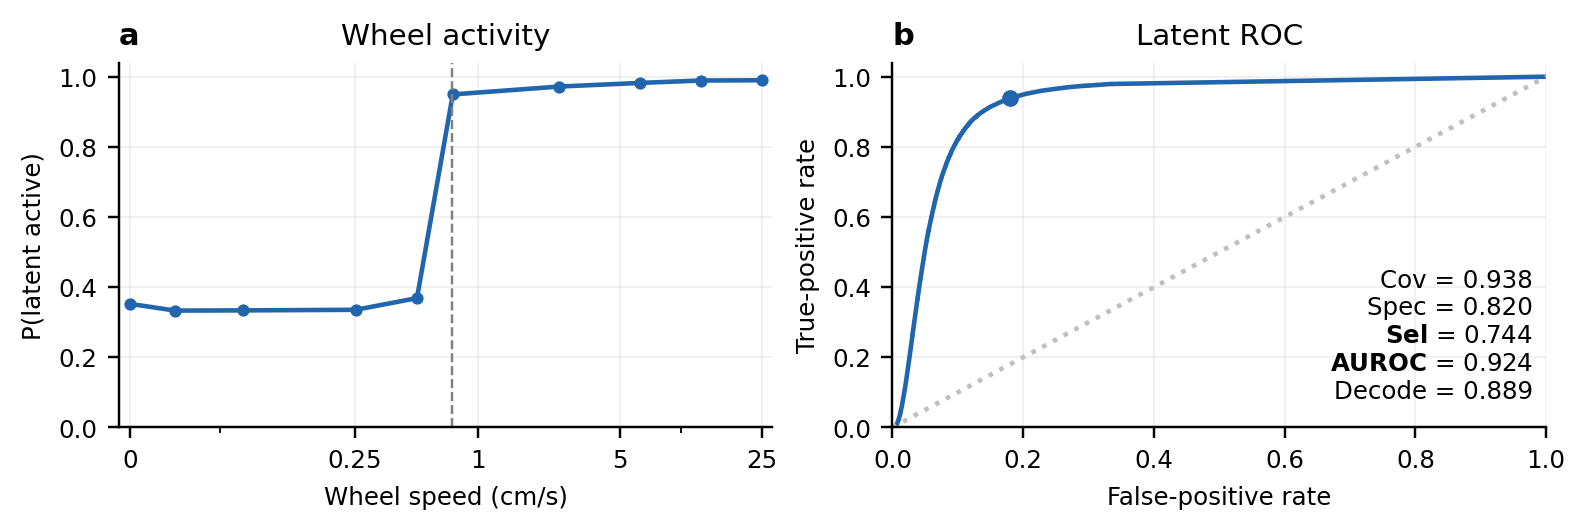

In [3]:
report.render_main()
display(Image(filename=str(report.FIGURES / "aeon_main.png")))

## Table S3 and Figures S16–S17: all four selected features

,D,K,latent,n_condition,n_outside,active_condition,active_outside,tpr,fpr,selectivity,precision,auroc,condition_episodes
feature,,,,,,,,,,,,,
wheel,192,12,52,93727,3144870,91784,1057208,0.979270,0.336169,0.744443,0.079882,0.924339,511
area,256,12,107,86046,346742,71994,82960,0.836692,0.239256,0.777633,0.464615,0.849219,1094
speed,256,12,109,640890,2563556,460154,560515,0.717992,0.218647,0.766562,0.450836,0.778473,5577
direction,256,12,10,15054,126541,12645,24669,0.839976,0.194949,0.811630,0.338881,0.871736,576


\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lrrrrrrrr@{}}
\toprule
Method & $D/k$ & Latent & \metric{Cov} & \metric{Spec} & \metric{Sel} & \metric{AUROC} & \shortstack{Single\\Decode} & \shortstack{All\\Decode} \\
\midrule
\multicolumn{9}{l}{\textit{Wheel activity}} \\
NLDisco & 192/12 & 52 & 0.9793 & 0.6638 & 0.744 & 0.924 & 0.8890 & 0.9328 \\
\midrule
\multicolumn{9}{l}{\textit{Smaller area near the patch}} \\
NLDisco & 256/12 & 107 & 0.8367 & 0.7607 & 0.778 & 0.849 & 0.7989 & 0.7937 \\
\midrule
\multicolumn{9}{l}{\textit{Highest centroid-speed quintile}} \\
NLDisco & 256/12 & 109 & 0.7180 & 0.7814 & 0.767 & 0.778 & 0.7118 & 0.7949 \\
\midrule
\multicolumn{9}{l}{\textit{Radially outward movement}} \\
NLDisco & 256/12 & 10 & 0.8400 & 0.8051 & 0.812 & 0.872 & 0.8550 & 0.9005 \\
\bottomrule
\end{tabular*}



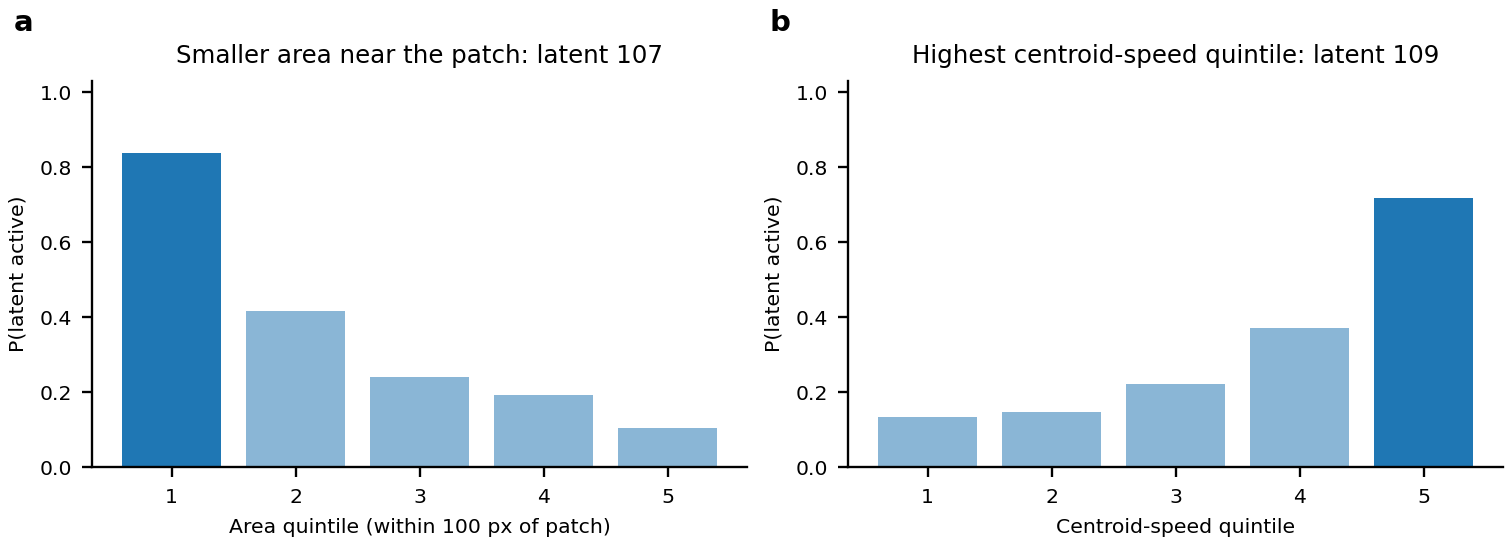

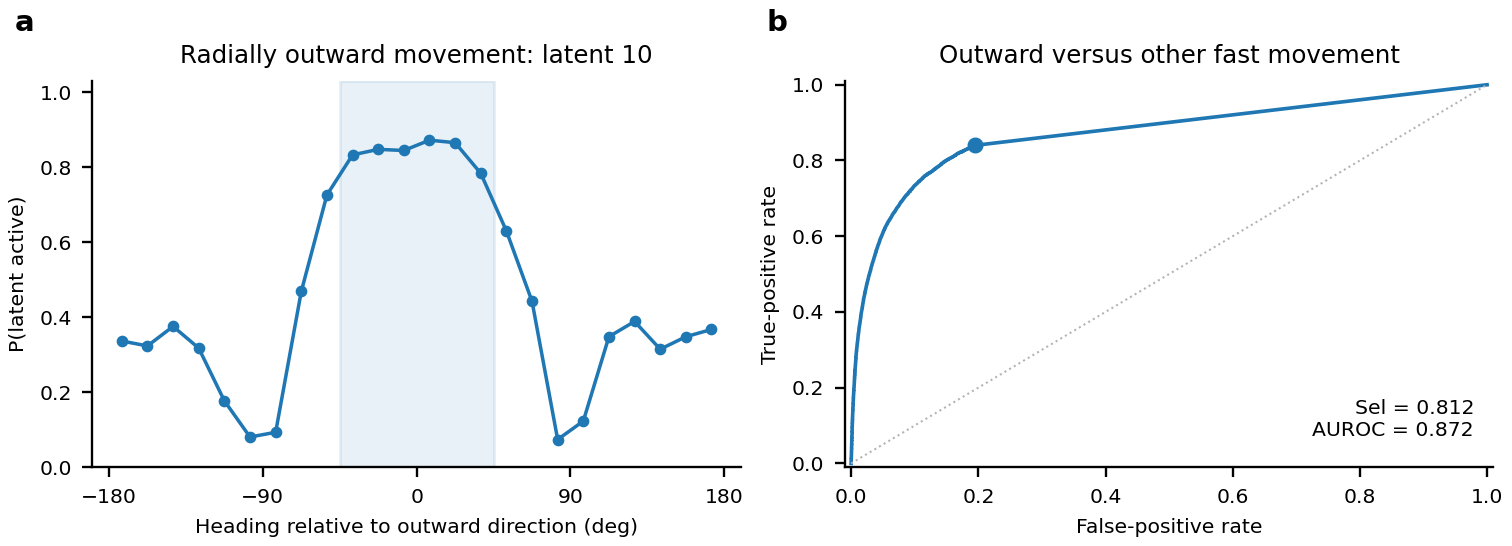

In [4]:
import pandas as pd
scores = pd.read_csv(report.source.OUT / "feature_scores.csv").set_index("feature")
report.plt.rcParams.update({"font.size": 7, "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42})
report.render_table(scores)
report.render_features(scores)
display(scores)
print((report.FIGURES / "aeon_feature_metrics.tex").read_text())
for name in ("aeon_additional_features", "aeon_direction"):
    display(Image(filename=str(report.FIGURES / f"{name}.png")))

## Figure S18: wheel-versus-patch activity

Recompute both excerpts from the native activation export and recorded behavior, preserving invalid-data markers. The generated JSON records tick counts and the difference from the current manuscript.

 track  active_windows  valid_windows  invalid_windows
 patch          438407        3208645            31355
 wheel           93727        3238597             1403
latent         1148995        3238600             1400


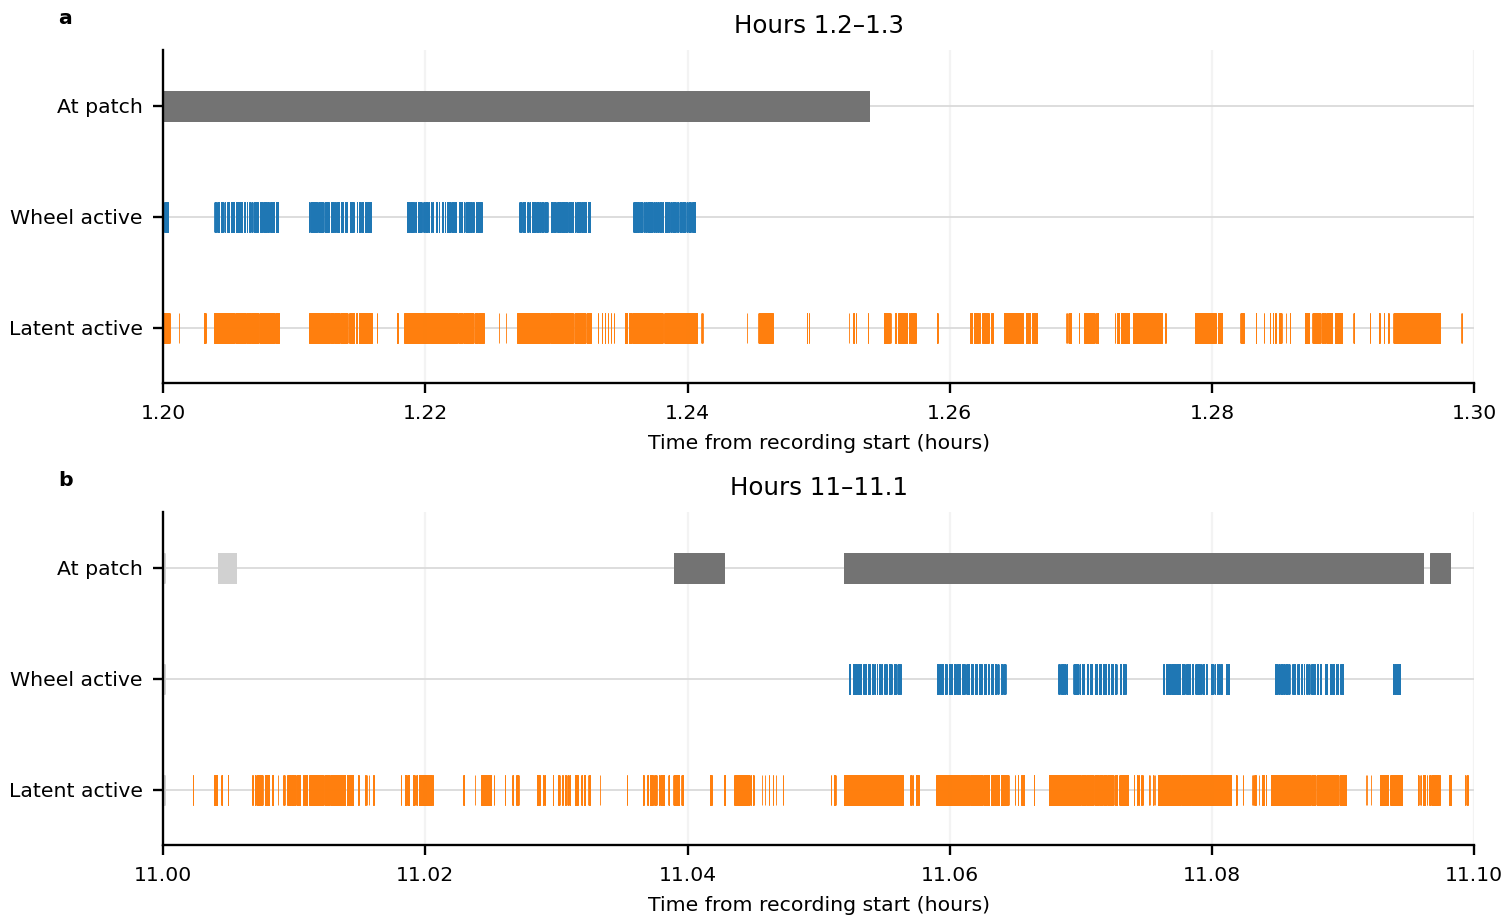

In [5]:
report.render_patch_control()
display(Image(filename=str(report.FIGURES / "aeon_wheel_vs_patch.png")))

## Figures S19–S20: source activity traceback and decoder weights

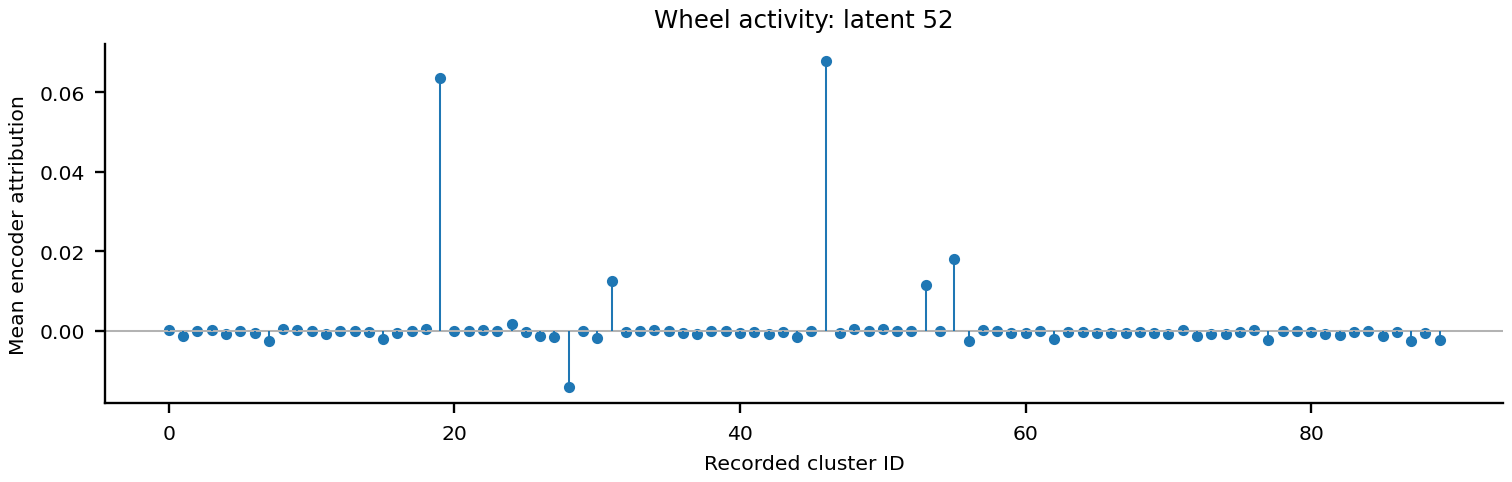

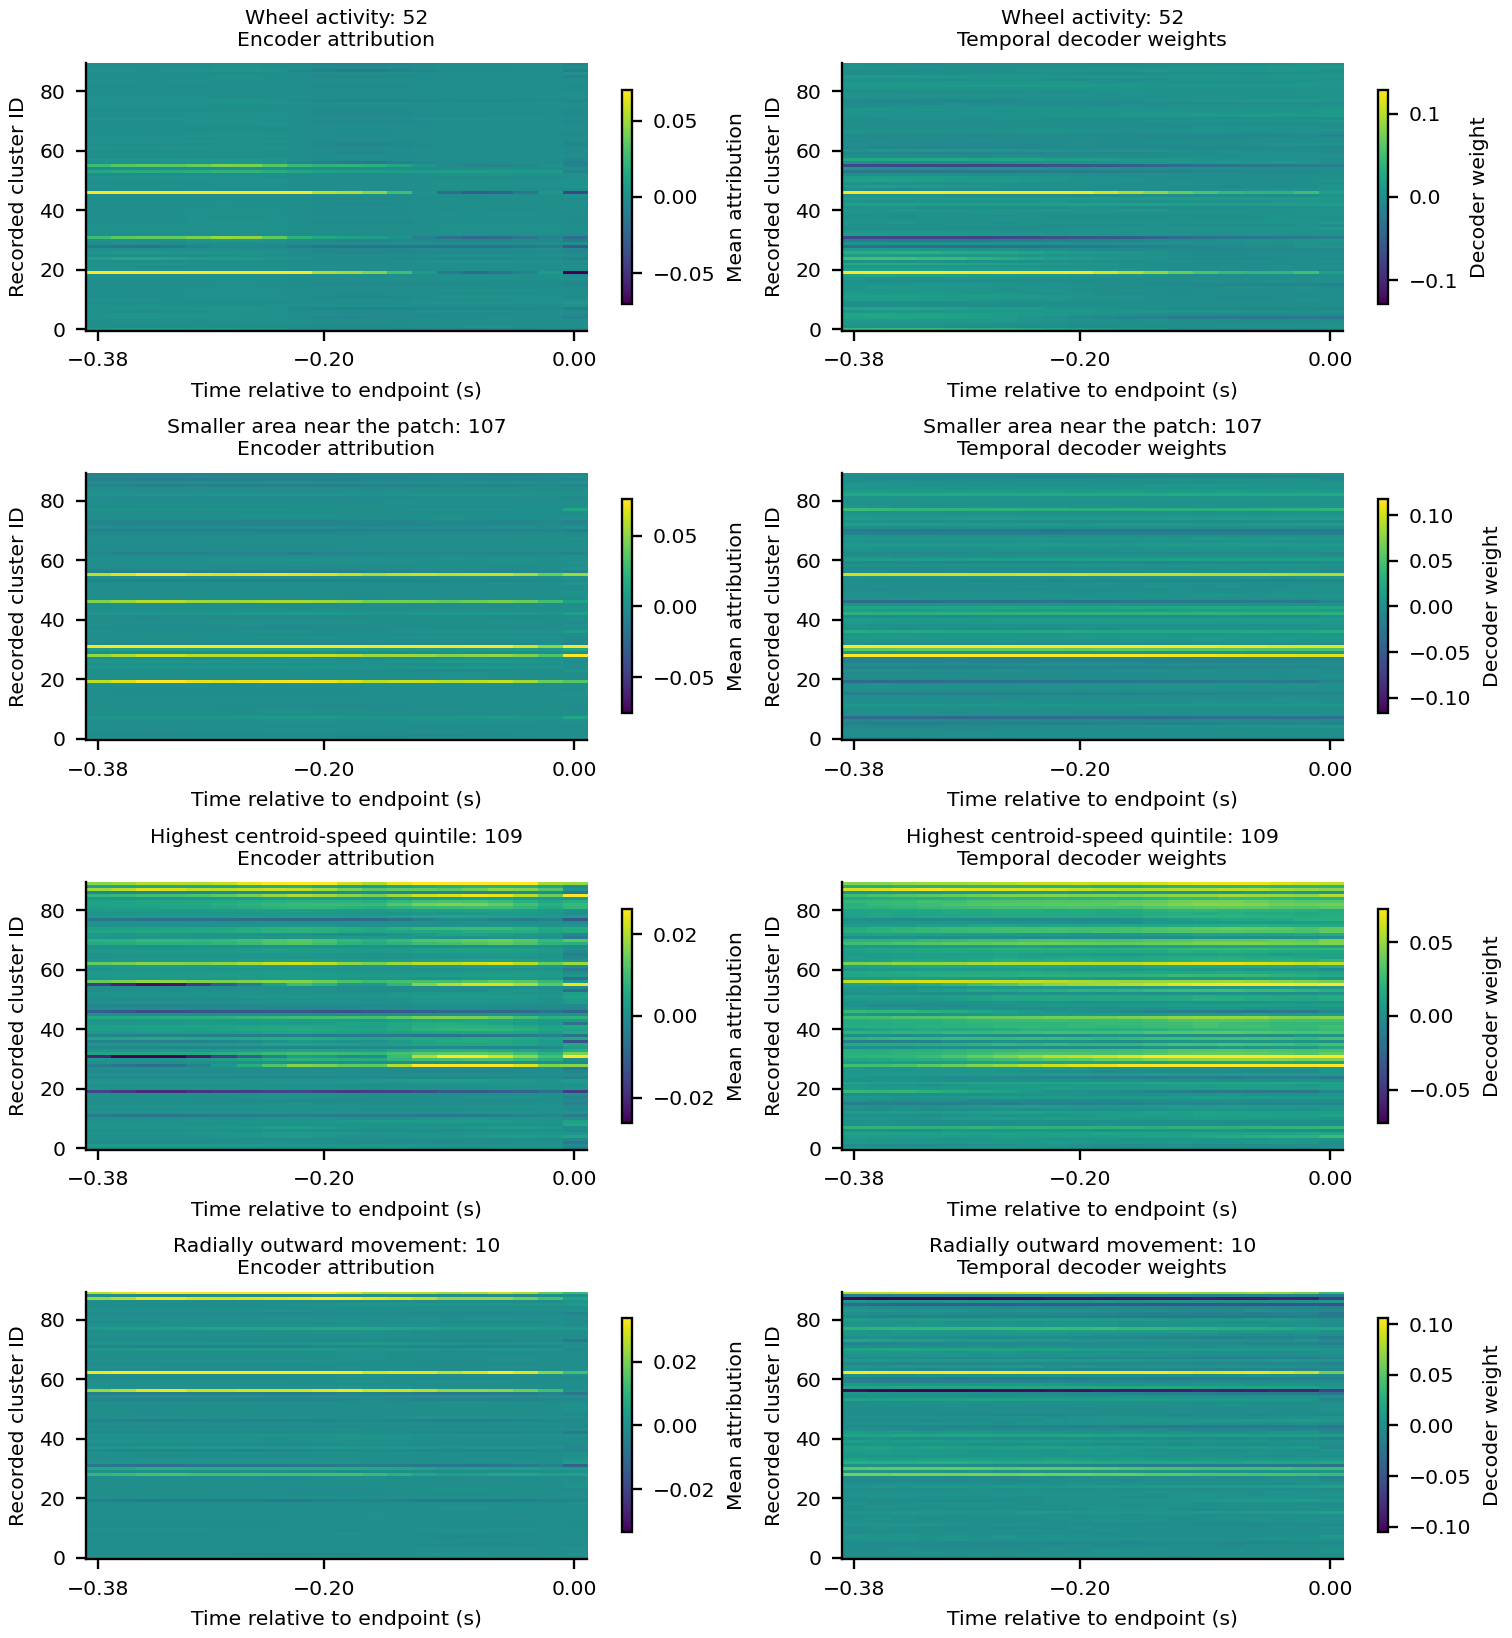

In [6]:
report.render_tracebacks()
for name in ("aeon_wheel_source_traceback", "aeon_traceback"):
    display(Image(filename=str(report.FIGURES / f"{name}.png")))